In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)


True

In [3]:
from src import data_load as dl
from src import preprocessing_pipeline as prp
from src import clustering as cl
from src import new_evaluation as ev
from src import optimization as opt
from src import visualisation as viz
from src import marker as mk
from src.graph import graph
from src.agent import cluster_node, evaluate_node, reflection_node, final_selection_node
from src.decision import (OptimizationDecision, FinalExperimentSelection,)
from src.no_biology_prompt import (build_reflection_prompt, build_final_selection_prompt) 
from src.experiment_logger import (create_experiment_log,save_experiment_log,add_final_result,)

import scanpy as sc
import pandas as pd
from langchain_openai.chat_models import ChatOpenAI 
from IPython.display import Image, display

In [30]:
# Stability analysis

from src.stability import run_stability_analysis, calculate_pairwise_ari, calculate_cluster_jaccard
import numpy as np
from collections import defaultdict
from collections import Counter

### Create the LLM (OPENAI)

In [4]:
llm = ChatOpenAI(model="gpt-5", temperature=0,)

## Fixed Preprocessing Pipeline

In [5]:
pbmc_data = dl.load_pbmc3k()
pbmc_data = prp.run_preprocessing_pipeline(pbmc_data)

Running QC...
Running normalization...
Running PCA...
Finished preprocessing.


In [6]:
pbmc_data.var["highly_variable"].sum()

np.int64(2000)

In [7]:
pbmc_data

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'scaled'

## Agent State Setup
The state acts as the agent's shared memory. Technically, LangGraph simply gives every node the same shared memory. Each node:

+ reads what it needs
+ updates what changed
+ returns the updated state

In this setup, it stores the dataset, current parameters, evaluation metrics, experiment history, and optimization progress, allowing each node in the LangGraph workflow to access the information it needs and update it as the optimization proceeds.


In [8]:
experiment_log = create_experiment_log( 
    experiment_id="EXP-028", 
    dataset="PBMC3K", 
    method="agentic_no_biology", 
    condition="no_biology", 
    agent_version="v0.5-refactored", 
    change=( "Refactored the reflection and final selection workflow, " 
             "added controlled LLM decision validation, duplicate " 
             "configuration checks, and a maximum experiment budget." ), 
    reason_for_change=( "To improve the reliability and reproducibility of agentic " 
                        "parameter exploration and to ensure that invalid or repeated " 
                        "LLM-proposed configurations are rejected before clustering." ), 
)

In [9]:
state = {
    "messages": [],

    "adata": pbmc_data,

    "parameters": {
        "n_neighbors": 15,
        "resolution": 1.0,
        "n_pcs": 20,
    },

    # Experimental condition
    "condition": "no_biology",

    "metrics": {},

    "history": [],

    "experiment_log": experiment_log,

    "iteration": 0,

    "decision": "continue",

    "reason": "",

    "evaluated_configs": [],

    "clustering_time": 0.0,

    "evaluation_time": 0.0,

    "llm_decision_time": 0.0,

    # Final selection fields
    "selected_iteration": None,

    "best_experiment": None,

    "final_selection_reason": None,

    "final_selection_time": 0.0,
}

In [10]:
print(pbmc_data.obsm["X_pca"].shape)

(2638, 50)


### Run Agentic Optimization

The following cell executes the agentic optimization workflow using the specified initial state and saves the resulting experiment log.

The agent will iteratively:
- run clustering,
- evaluate the clustering,
- request an LLM reflection/parameter decision,
- continue until the exploration budget is reached or the LLM decides to stop,
- and finally select the preferred experiment from the completed history.


In [11]:
result = graph.invoke(state)

save_experiment_log(result["experiment_log"])


CURRENT EVALUATION
Clusters: 10
Silhouette: 0.0748
DBI: 2.6664
WC-dispersion: 374182.5000
Banfield-Raftery: 12939.8262

LLM PROMPT

You are an expert in single-cell RNA-seq clustering optimization.

Your objective is to explore clustering parameters and identify
parameter configurations that provide strong overall clustering
evidence while avoiding unnecessary over-fragmentation or
under-clustering.

The optimization should balance potential improvement against the
cost of additional experiments. Do not continue exploring merely
for the sake of using the available experiment budget.

NO-BIOLOGY EXPERIMENTAL CONDITION:

This is the no-biology experimental condition.

* Do not use marker genes, cell-type annotations, biological labels,
  known cell identities, or biological interpretations.
* Base all optimization decisions exclusively on intrinsic clustering
  metrics and cluster-structure information provided in the prompt.
* Do not infer or assume biological cell identities.
* Biolog

PosixPath('experiments/EXP-028.json')

In [12]:
# print(graph.get_graph().draw_mermaid())

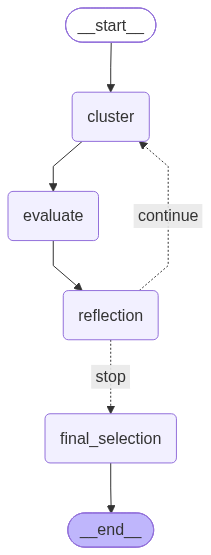

In [13]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
print("Decision:", result["decision"])
print("Reason:", result["reason"])

Decision: stop
Reason: Maximum number of experiments (3) reached.


In [15]:
state.keys()

dict_keys(['messages', 'adata', 'parameters', 'condition', 'metrics', 'history', 'experiment_log', 'iteration', 'decision', 'reason', 'evaluated_configs', 'clustering_time', 'evaluation_time', 'llm_decision_time', 'selected_iteration', 'best_experiment', 'final_selection_reason', 'final_selection_time'])

In [16]:
# print(type(decision))

In [19]:
for experiment in result["history"]:
    print("\nIteration:", experiment["iteration"])
    print(
        "Parameters:",
        experiment["parameters"]
    )
    print(
        "Silhouette:",
        experiment["metrics"]["silhouette_score"]
    )
    print(
        "DBI:",
        experiment["metrics"][
            "davies_bouldin_score"
        ]
    )
    print(
        "WC-dispersion:",
        experiment["metrics"][
            "wc_dispersion_score"
        ]
    )
    print(
        "Banfield-Raftery:",
        experiment["metrics"][
            "banfield_raftery_score"
        ]
    )
    print(
        "Clusters:",
        experiment["metrics"]["n_clusters"]
    )


Iteration: 0
Parameters: {'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20}
Silhouette: 0.07478884607553482
DBI: 2.666380841974742
WC-dispersion: 374182.5
Banfield-Raftery: 12939.826171875
Clusters: 10

Iteration: 1
Parameters: {'n_neighbors': 30, 'resolution': 1.0, 'n_pcs': 20}
Silhouette: 0.07592421770095825
DBI: 2.642627108830443
WC-dispersion: 374449.28125
Banfield-Raftery: 12955.75390625
Clusters: 9

Iteration: 2
Parameters: {'n_neighbors': 30, 'resolution': 0.8, 'n_pcs': 20}
Silhouette: 0.08012446761131287
DBI: 2.633756724188635
WC-dispersion: 374189.03125
Banfield-Raftery: 12951.6552734375
Clusters: 9


In [25]:
best_experiment = result["history"][2]

best_params = best_experiment["parameters"]

print(best_params)

{'n_neighbors': 30, 'resolution': 0.8, 'n_pcs': 20}


In [21]:
pbmc_data_best = cl.run_clustering(
    pbmc_data.copy(),
    n_neighbors=best_params["n_neighbors"],
    resolution=best_params["resolution"],
    n_pcs=best_params["n_pcs"],)

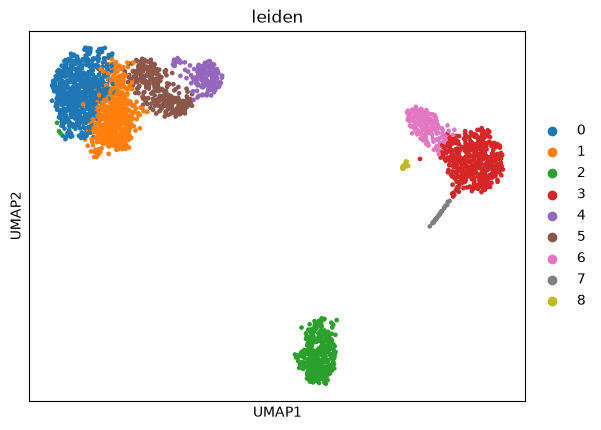

In [22]:
viz.plot_umap(pbmc_data_best, color="leiden")

In [23]:
ev.get_cluster_summary(pbmc_data_best)

{'0': 655,
 '1': 519,
 '2': 348,
 '3': 469,
 '4': 159,
 '5': 281,
 '6': 167,
 '7': 27,
 '8': 13}

## Stability Analysis

Initial robustness check

In [28]:
stability_no_biology = run_stability_analysis(
    pbmc_data,
    n_neighbors=30,
    resolution=0.8,
    n_pcs=20,
    seeds=range(10),
)

print("Cluster counts:", stability_no_biology["cluster_counts"])

Cluster counts: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]


In [31]:
cluster_count_frequency = Counter(stability_no_biology["cluster_counts"])

print("Cluster count frequency:")
for k, count in sorted(cluster_count_frequency.items()):
    print(f"K={k}: {count}/10 runs")

Cluster count frequency:
K=9: 10/10 runs


In [32]:
ari_scores = calculate_pairwise_ari(stability_no_biology["assignments"])

print("Number of pairwise comparisons:", len(ari_scores))
print("Mean ARI:", sum(ari_scores) / len(ari_scores), end="\n")
print("-----------------")
print("Stability summary")
print("-----------------")
print(f"Mean ARI:   {np.mean(ari_scores):.4f}",  end='\n')
print(f"Median ARI: {np.median(ari_scores):.4f}",  end='\n')
print(f"SD ARI:     {np.std(ari_scores):.4f}",  end='\n')
print(f"Min ARI:    {np.min(ari_scores):.4f}",  end='\n')
print(f"Max ARI:    {np.max(ari_scores):.4f}")

Number of pairwise comparisons: 45
Mean ARI: 0.8755959857671682
-----------------
Stability summary
-----------------
Mean ARI:   0.8756
Median ARI: 0.8712
SD ARI:     0.0465
Min ARI:    0.7806
Max ARI:    0.9712
